
Opening HDF5 file...

Top-level structure:
  Total entries: 12
  Number of halos: 11
  Example halos: ['halo_0', 'halo_1', 'halo_13', 'halo_2', 'halo_3']
  Other entries: ['units']
    → 'units' contains the physical units for each dataset

(Set PRINT_ALL_HALO_NAMES = True to list all 11 halos)


--- Field Summary (from halo_0) ---

Note:
  Shape → number of values in dataset
  Type  → data type
  Unit  → physical unit (if available)

Field                               Shape                Type         Unit
--------------------------------------------------------------------------------
angular_momentum                    (3,)                 float32      Mpc*Msun*km/(h**2*s)
bh_particle_IDs                     (7,)                 float64      -
gas_mass                            (303658,)            float64      g (grams)
pop2_metallicity_fraction           (11,)                float64      code_metallicity
pop2_stellar_age                    (11,)                float64      yr
p

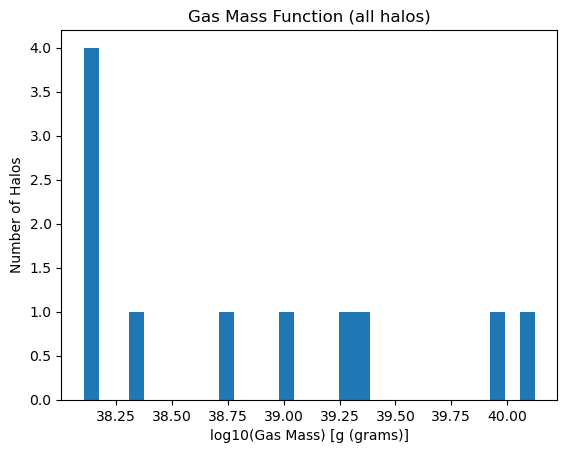


Done! You have successfully explored the file.


In [3]:
# This notebook performs a full exploration of the halo catalog.
# If you are new, start with the basic notebook first. 
    

import h5py
import numpy as np
import matplotlib.pyplot as plt


# UPDATE PATH: This is the path to your HDF5 file
#current path calls to a practice file
file_path = "practice_halo_catalog.hdf5"

# USER TOGGLES
PRINT_ALL_HALO_NAMES = False     # prints just the names of halos (long)
PRINT_ALL_HALOS = False          # prints EVERYTHING inside every halo (very long)


print("\nOpening HDF5 file...\n")

# Open the HDF5 file
with h5py.File(file_path, "r") as f:

 
    # 0. LOAD UNITS (metadata)
    # The file has a special "units" group that tells us what physical units each halo attribute uses
    units = f["units"].attrs if "units" in f else {}

    # Helper function: safely get unit for any dataset
    def get_unit(name):
        val = units.get(name, "")

        # decode bytes → string
        if isinstance(val, bytes):
            val = val.decode()

        # clean up less helpful labels
        if val in ["unitary", "dimensionless"]:
            return ""
        if val == "g":
            return "g (grams)"

        return val


    # 1. TOP-LEVEL STRUCTURE
 
    # The HDF5 file is like a dictionary:
    # f.keys() = everything at the top level

    keys = list(f.keys())

    # Separate halos from other groups (like "units")
    halo_names = [k for k in keys if k.startswith("halo_")]
    other_keys = [k for k in keys if not k.startswith("halo_")]

    print("Top-level structure:")
    print(f"  Total entries: {len(keys)}")
    print(f"  Number of halos: {len(halo_names)}")
    print(f"  Example halos: {halo_names[:5]}")

    if len(other_keys) > 0:
        print(f"  Other entries: {other_keys}")
        if "units" in other_keys:
            print("    → 'units' contains the physical units for each dataset")

    print()


    # OPTIONAL: print all halo names
    # This shows how many halos exist and what they are called
    if PRINT_ALL_HALO_NAMES:
        print("\n--- Full list of halo names ---\n")

        for i, name in enumerate(halo_names):
            print(name)

            # progress for very large files
            if i % 500 == 0 and i != 0:
                print(f"... printed {i} halos so far ...")

        print(f"\nTotal halos listed: {len(halo_names)}\n")
    else:
        print(f"(Set PRINT_ALL_HALO_NAMES = True to list all {len(halo_names)} halos)\n")


    # 2. ACCESSING A SINGLE HALO
    # Each halo is like a folder:
    # f["halo_0"] gives you everything inside that halo

    #access list made of halo names
    example_halo = halo_names[0]
    halo = f[example_halo]

    print(f"\n--- Field Summary (from {example_halo}) ---\n")

    print("Note:")
    print("  Shape → number of values in dataset")
    print("  Type  → data type")
    print("  Unit  → physical unit (if available)\n")

    print(f"{'Field':<35} {'Shape':<20} {'Type':<12} {'Unit'}")
    print("-" * 80)

    # Loop through everything inside ONE halo
    for key in sorted(halo.keys()):

        # Each entry is either a dataset (array) or group
        obj = halo[key]

        if isinstance(obj, h5py.Dataset):
            shape = str(obj.shape)
            dtype = str(obj.dtype)

            unit = get_unit(key)
            if unit == "":
                unit = "-"

            print(f"{key:<35} {shape:<20} {dtype:<12} {unit}")

            
    # OPTIONAL: inspect ALL halos deeply
    if PRINT_ALL_HALOS:
        print("\n--- Inspecting ALL halos (very long output!) ---\n")

        for i, name in enumerate(halo_names):

            if i % 100 == 0:
                print(f"  Processing halo {i+1}/{len(halo_names)}")

            h = f[name]

            print(f"\n{name}:")
            for key in sorted(h.keys()):
                obj = h[key]
                if isinstance(obj, h5py.Dataset):
                    print(f"  {key}: shape={obj.shape}, dtype={obj.dtype}")
    else:
        print(f"\n(Set PRINT_ALL_HALOS = True to inspect all {len(halo_names)} halos)\n")


    # 3. COLLECT DATA FROM ALL HALOS
    # This is the key idea:
    # We LOOP through halos and extract specific fields

    print("Collecting data from ALL halos...\n")

    uv_mags = []       # store UV brightness values
    gas_masses = []    # store halo gas masses

    gas_unit_name = "total_gas_mass"

    for i, name in enumerate(halo_names):

        # progress indicator
        if i % 100 == 0:
            print(f"  Processing halo {i+1}/{len(halo_names)}")

        h = f[name]

        # Access dataset inside halo:
        # h["absolute_magnitude_UV"]
        if "absolute_magnitude_UV" in h:
            uv_mags.extend(h["absolute_magnitude_UV"][:])

        # Some halos store total mass directly
        if "total_gas_mass" in h:
            gas_masses.append(h["total_gas_mass"][()])
            gas_unit_name = "total_gas_mass"

        # Others require summing particle data
        elif "gas_mass" in h:
            gas_masses.append(np.sum(h["gas_mass"][()]))
            gas_unit_name = "gas_mass"

    print(f"\nFinished processing {len(halo_names)} halos.\n")

    # Convert to numpy arrays for analysis
    uv_mags = np.array(uv_mags)
    gas_masses = np.array(gas_masses)


    # 4. EXAMPLE PLOTS

    # UV Luminosity Function
    if len(uv_mags) > 0:
        plt.figure()
        plt.hist(uv_mags, bins=30)
        plt.xlabel("Absolute UV Magnitude")
        plt.ylabel("Number of Galaxies")
        plt.title("UV Luminosity Function (all halos)")
        plt.gca().invert_xaxis()  # brighter = more negative
        plt.show()

    # Gas Mass Function
    if len(gas_masses) > 0:
        plt.figure()
        plt.hist(np.log10(gas_masses), bins=30)
        plt.xlabel(f"log10(Gas Mass) [{get_unit(gas_unit_name)}]")
        plt.ylabel("Number of Halos")
        plt.title("Gas Mass Function (all halos)")
        plt.show()

print("\nDone! You have successfully explored the file.")

  